# Tugas - Klasifikasi dengan Decision Tree

| Nama                   | NRP        |
|------------------------|------------|
| Muhammad Fardan Hafidz | 5054251021 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset: Taiwan Bankruptcy Prediction ([Kaggle - bankruptcy](https://www.kaggle.com/datasets/abbas829/bankruptcy), file lokal `bankruptcy.csv`).

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [20]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42

In [21]:
# Load dataset dan tampilkan informasi dasar
import os

LOCAL_CSV = "bankruptcy.csv" # kalo lokal
COLAB_CSV_URL = "https://raw.githubusercontent.com/fardan-college-repositories/praktikum-ml/main/3.%20Tugas_Decision%20Tree%20Classifier/bankruptcy.csv"  # kalo colab/kaggle

if os.path.exists(LOCAL_CSV):
    CSV_PATH = LOCAL_CSV
    print(f"Memuat dataset lokal: {CSV_PATH}")
elif COLAB_CSV_URL:
    CSV_PATH = COLAB_CSV_URL
    print(f"File lokal tidak ditemukan, mengunduh CSV dari link:\n{CSV_PATH}")
else:
    raise FileNotFoundError(
        "File 'bankruptcy.csv' tidak ditemukan. "
        "Kalau di Colab: isi COLAB_CSV_URL di cell ini, "
        "atau upload bankruptcy.csv ke session Colab (atau mount Google Drive)."
    )

df = pd.read_csv(CSV_PATH)
# Bersihkan spasi berlebih pada nama kolom (nama kolom asli diawali spasi)
df.columns = df.columns.str.strip()

print("Jumlah baris dan kolom:", df.shape)
print("\nTipe data:")
print(df.dtypes.value_counts())
print("\nInfo kolom:")
df.info()
print("\nStatistik deskriptif (5 kolom pertama):")
display(df.describe().iloc[:, :5])
print("\nJumlah missing value per kolom (total):", int(df.isna().sum().sum()))
print("Jumlah baris duplikat:", int(df.duplicated().sum()))
print("\nJumlah unique per kolom (5 terkecil):")
display(df.nunique().sort_values().head(10))

File lokal tidak ditemukan, mengunduh CSV dari link:
https://raw.githubusercontent.com/fardan-college-repositories/praktikum-ml/main/3.%20Tugas_Decision%20Tree%20Classifier/bankruptcy.csv
Jumlah baris dan kolom: (6819, 96)

Tipe data:
float64    93
int64       3
Name: count, dtype: int64

Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948
std,0.176710,0.060686,0.065620,0.061595,0.016934
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445
50%,0.000000,0.502706,0.559802,0.552278,0.605997
75%,0.000000,0.535563,0.589157,0.584105,0.613914
max,1.000000,1.000000,1.000000,1.000000,1.000000



Jumlah missing value per kolom (total): 0
Jumlah baris duplikat: 0

Jumlah unique per kolom (5 terkecil):


,0
Net Income Flag,1
Bankrupt?,2
Liability-Assets Flag,2
Total Asset Turnover,381
Net Worth Turnover Rate (times),741
Interest-bearing debt interest rate,1080
Operating Profit Per Share (Yuan ¥),1236
Persistent EPS in the Last Four Seasons,1358
Per Share Net profit before tax (Yuan ¥),1522
Research and development expense rate,1536


Bankrupt?
0    6599
1     220
Name: count, dtype: int64
Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64

Rasio imbalance: 6599 : 220 (~3.23% kelas bangkrut)


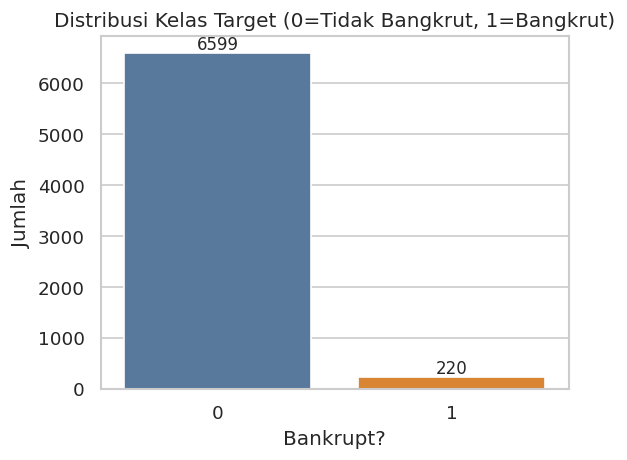

In [22]:
# Tampilkan distribusi kelas target dalam bentuk bar plot
TARGET = "Bankrupt?"
counts = df[TARGET].value_counts().sort_index()
props = df[TARGET].value_counts(normalize=True).sort_index()
print(counts)
print(props)
print(f"\nRasio imbalance: {counts[0]} : {counts[1]} (~{props[1]*100:.2f}% kelas bangkrut)")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=TARGET, data=df, hue=TARGET, palette=["#4C78A8", "#F58518"], legend=False, ax=ax)
ax.set_title("Distribusi Kelas Target (0=Tidak Bangkrut, 1=Bangkrut)")
ax.set_xlabel("Bankrupt?")
ax.set_ylabel("Jumlah")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2., p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

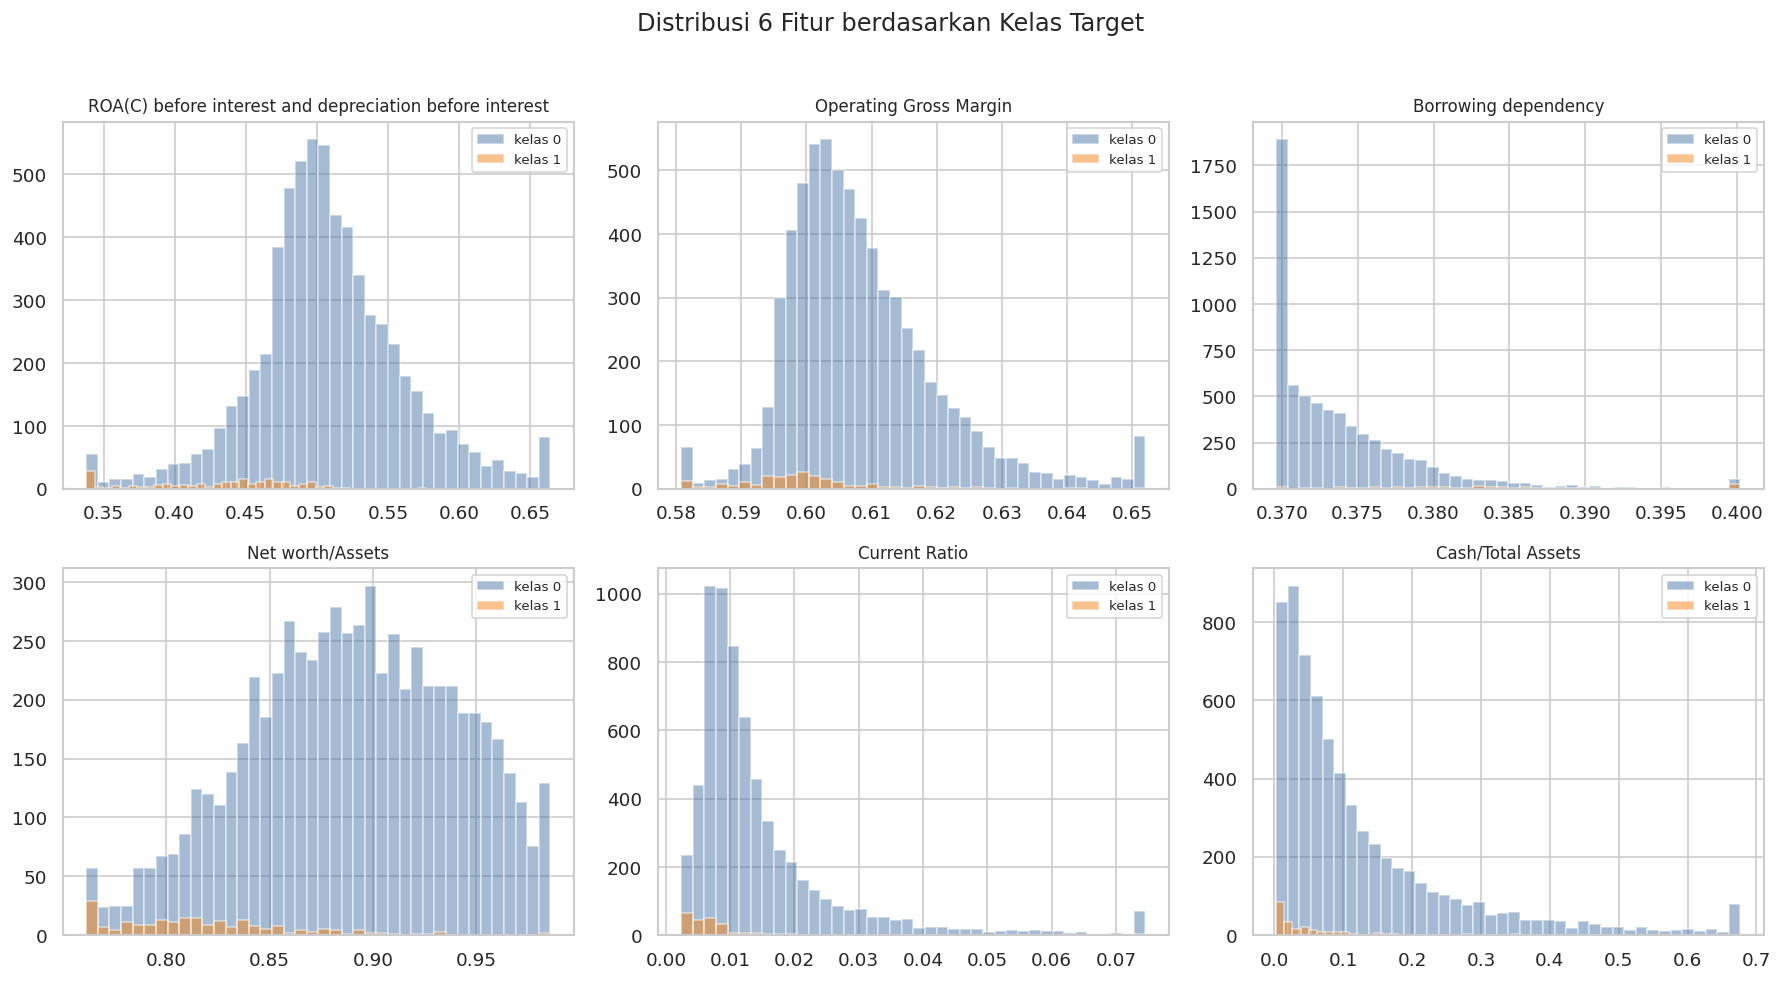

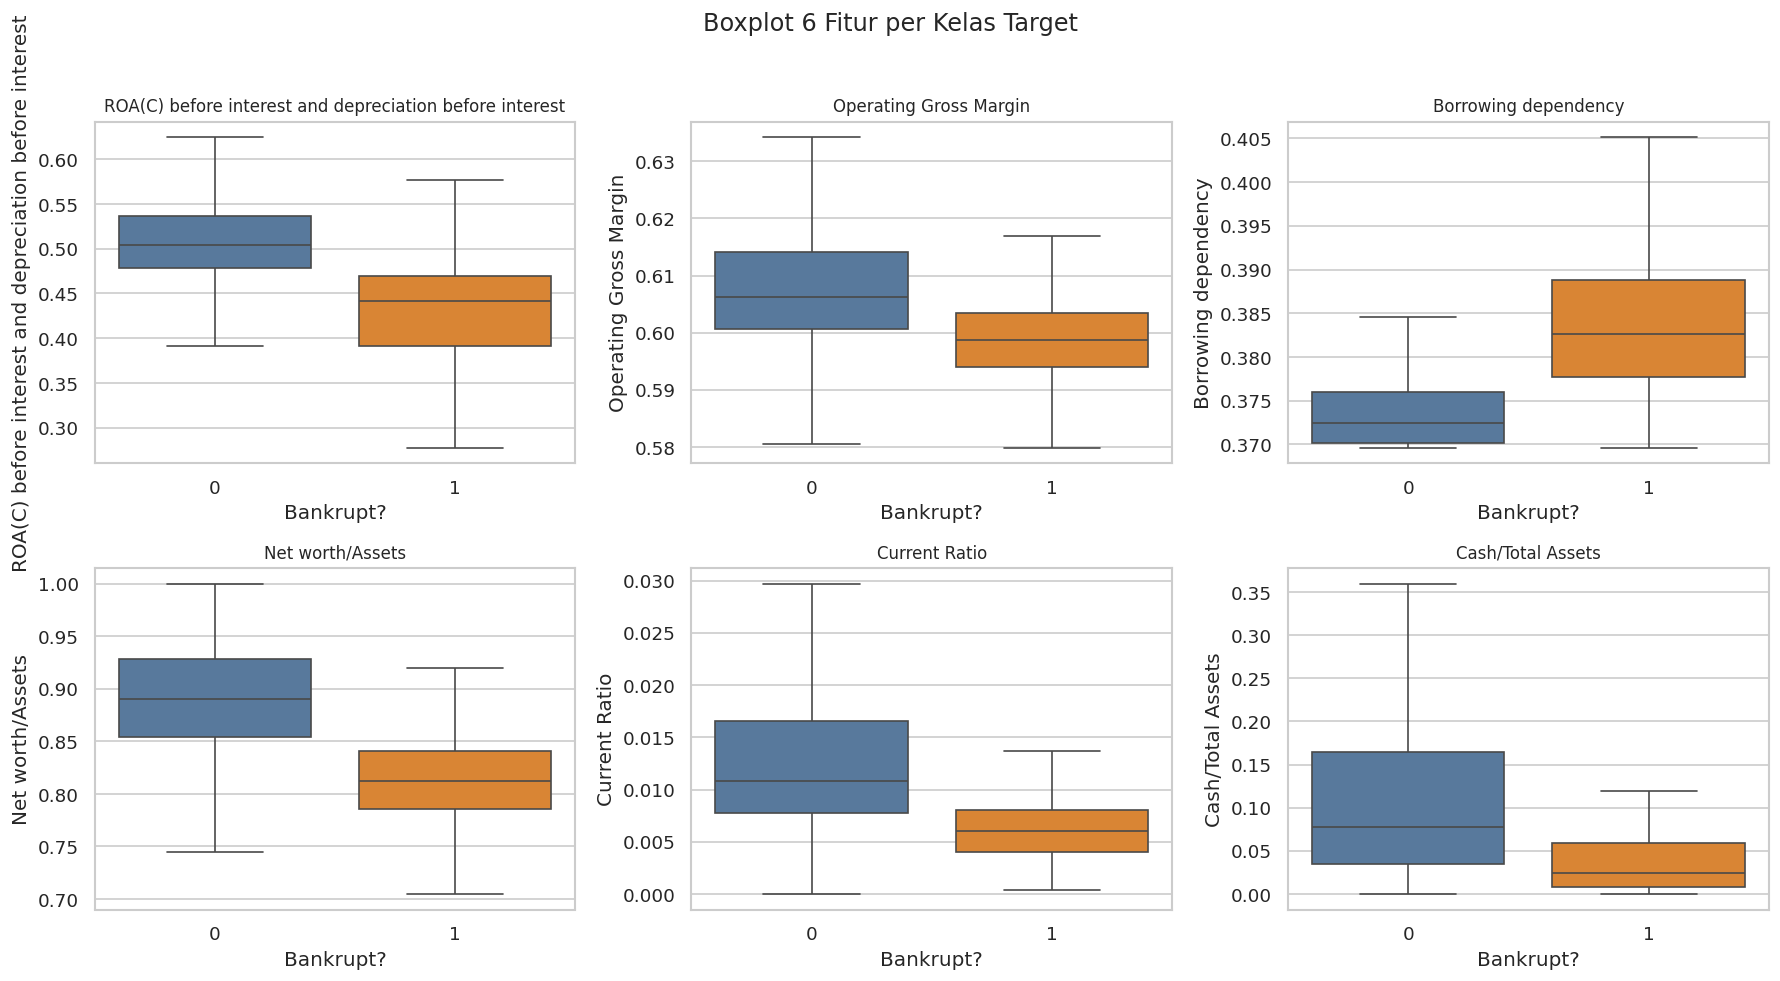

In [23]:
# Distribusi / hubungan antar fitur dibedakan berdasarkan kelas target
# Dataset punya 94 fitur numerik -> tampilkan histogram + boxplot untuk 6 fitur representatif
features_show = ["ROA(C) before interest and depreciation before interest",
                 "Operating Gross Margin",
                 "Borrowing dependency",
                 "Net worth/Assets",
                 "Current Ratio",
                 "Cash/Total Assets"]
for c in features_show:
    assert c in df.columns, f"kolom tidak ditemukan: {c}"

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, features_show):
    for cls, color in zip([0, 1], ["#4C78A8", "#F58518"]):
        vals = df.loc[df[TARGET] == cls, col].to_numpy()
        # clip ekstrim 1%-99% agar histogram terbaca (beberapa kolom ada outlier miliaran)
        lo, hi = np.percentile(df[col].to_numpy(), [1, 99])
        vals = np.clip(vals, lo, hi)
        ax.hist(vals, bins=40, label=f"kelas {cls}", color=color, alpha=0.5)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle("Distribusi 6 Fitur berdasarkan Kelas Target", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, features_show):
    sns.boxplot(x=TARGET, y=col, data=df, hue=TARGET, palette=["#4C78A8", "#F58518"], legend=False, ax=ax, showfliers=False)
    ax.set_title(col, fontsize=10)
plt.suptitle("Boxplot 6 Fitur per Kelas Target", y=1.02)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA) tambahan

Kolom object: []
Kolom konstan (1 nilai unik): ['Net Income Flag']

Top 10 fitur berkorelasi positif dengan kebangkrutan:


,Bankrupt?
Debt ratio %,0.250161
Current Liability to Assets,0.194494
Borrowing dependency,0.176543
Current Liability to Current Assets,0.171306
Liability to Equity,0.166812
Current Liabilities/Equity,0.153828
Current Liability to Equity,0.153828
Liability-Assets Flag,0.139212
Total expense/Assets,0.139049
Equity to Long-term Liability,0.139014



Top 10 fitur berkorelasi negatif dengan kebangkrutan:


,Bankrupt?
Per Share Net profit before tax (Yuan ¥),-0.201395
Net profit before tax/Paid-in capital,-0.207857
Retained Earnings to Total Assets,-0.217779
Persistent EPS in the Last Four Seasons,-0.219560
Net worth/Assets,-0.250161
ROA(C) before interest and depreciation before interest,-0.260807
ROA(B) before interest and depreciation after tax,-0.273051
ROA(A) before interest and % after tax,-0.282941
Net Income to Total Assets,-0.315457
Net Income Flag,NaN


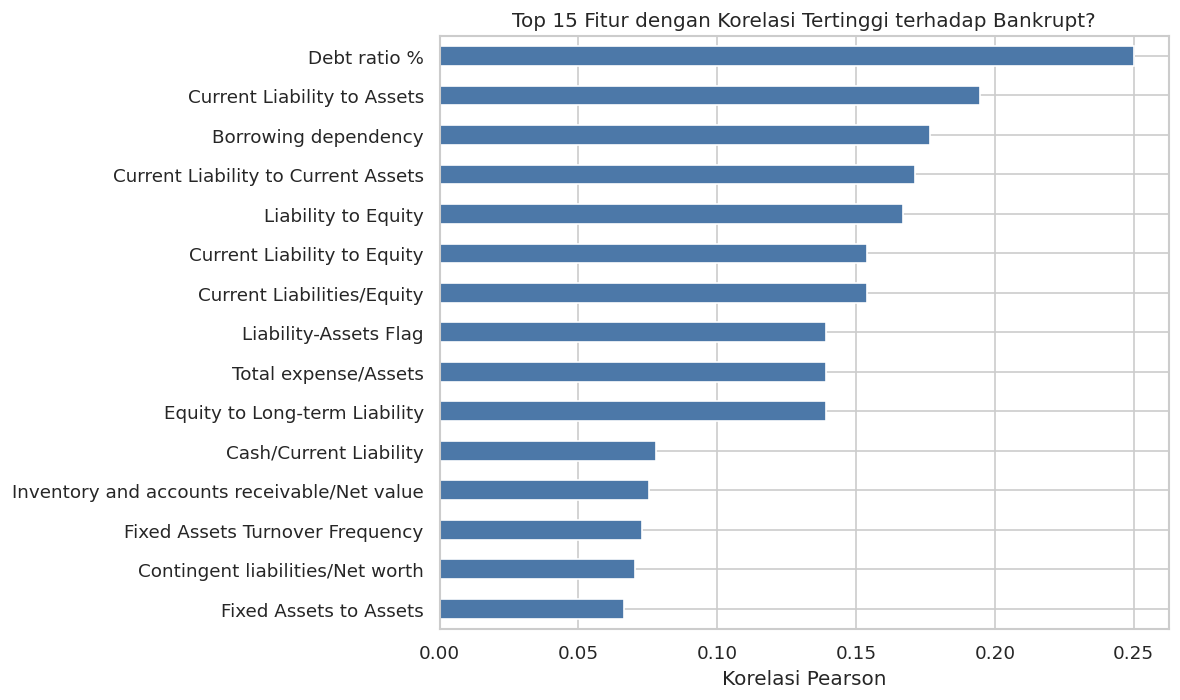

Bankrupt?,0,1
Liability-Assets Flag,,
0,0.969,0.031
1,0.250,0.750


In [24]:
# EDA tambahan: korelasi fitur terhadap target + cek kolom konstan/kategorikal
# 1. Semua fitur sudah numerik (tidak ada kolom object) -> tidak perlu encoding kategori
print("Kolom object:", df.select_dtypes(include="object").columns.tolist())

# 2. Cek kolom konstan (zero-variance) yang tidak berguna untuk split
const_cols = df.columns[df.nunique() <= 1].tolist()
print("Kolom konstan (1 nilai unik):", const_cols)

# 3. Korelasi Pearson tiap fitur terhadap target
corr = df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(ascending=False)
print("\nTop 10 fitur berkorelasi positif dengan kebangkrutan:")
display(corr.head(10))
print("\nTop 10 fitur berkorelasi negatif dengan kebangkrutan:")
display(corr.tail(10))

plt.figure(figsize=(10, 6))
corr.head(15).sort_values().plot(kind="barh", color="#4C78A8")
plt.title("Top 15 Fitur dengan Korelasi Tertinggi terhadap Bankrupt?")
plt.xlabel("Korelasi Pearson")
plt.tight_layout()
plt.show()

# 4. Crosstab flag biner yang tersedia
if "Liability-Assets Flag" in df.columns:
    display(pd.crosstab(df["Liability-Assets Flag"], df[TARGET], normalize="index").round(3))

# 2. Preprocessing

In [25]:
# Tangani missing value (jika ada)
print("Total missing:", int(df.isna().sum().sum()))
# Hasil: tidak ada missing value pada dataset ini, jadi tidak perlu imputasi.
# Jika ada missing, strategi yang aman dari leakage adalah imputasi memakai
# median/mean yang dihitung HANYA dari train set (mis. via SimpleImputer + Pipeline).
df_clean = df.copy()

Total missing: 0


In [26]:
# Encoding fitur kategorikal (jika ada)
# Pengecekan: semua kolom bertipe numerik -> tidak ada yang perlu di-encoding.
print(df_clean.dtypes.value_counts())
# DecisionTreeClassifier sklearn butuh input angka; karena semua fitur sudah angka,
# langkah encoding dilewati. Satu-satunya kolom non-informatif adalah kolom konstan:
if "Net Income Flag" in df_clean.columns:
    print("Net Income Flag unique:", df_clean["Net Income Flag"].unique())
    df_clean = df_clean.drop(columns=["Net Income Flag"])
    print("Kolom 'Net Income Flag' dibuang (konstan=1, tidak bisa dipakai untuk split).")
print("Shape setelah drop kolom konstan:", df_clean.shape)

float64    93
int64       3
Name: count, dtype: int64
Net Income Flag unique: [1]
Kolom 'Net Income Flag' dibuang (konstan=1, tidak bisa dipakai untuk split).
Shape setelah drop kolom konstan: (6819, 95)


In [27]:
# Pisahkan fitur (X) dan target (y), lalu split train/test 80:20 dengan stratify
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Distribusi train:", y_train.value_counts().to_dict())
print("Distribusi test :", y_test.value_counts().to_dict())
print(f"Proporsi kelas 1 - train: {y_train.mean():.4f}, test: {y_test.mean():.4f} (stratify menjaga proporsi)")

X_train: (5455, 94) | X_test: (1364, 94)
Distribusi train: {0: 5279, 1: 176}
Distribusi test : {0: 1320, 1: 44}
Proporsi kelas 1 - train: 0.0323, test: 0.0323 (stratify menjaga proporsi)


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [28]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini'
model_gini = DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE)
model_gini.fit(X_train, y_train)
print(f"Kedalaman pohon: {model_gini.get_depth()}, jumlah daun: {model_gini.get_n_leaves()}")
print(f"Akurasi train: {accuracy_score(y_train, model_gini.predict(X_train)):.4f}")

Kedalaman pohon: 19, jumlah daun: 125
Akurasi train: 1.0000


In [29]:
# Prediksi pada test set (model Gini)
y_pred_gini = model_gini.predict(X_test)
print("Contoh 10 prediksi pertama:", y_pred_gini[:10])
print("Distribusi prediksi:", pd.Series(y_pred_gini).value_counts().to_dict())

Contoh 10 prediksi pertama: [0 0 0 0 0 0 0 0 0 0]
Distribusi prediksi: {0: 1320, 1: 44}


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [30]:
# Latih model dengan criterion='entropy', hyperparameter lain sama agar adil
model_entropy = DecisionTreeClassifier(criterion="entropy", random_state=RANDOM_STATE)
model_entropy.fit(X_train, y_train)
print(f"Kedalaman pohon: {model_entropy.get_depth()}, jumlah daun: {model_entropy.get_n_leaves()}")
print(f"Akurasi train: {accuracy_score(y_train, model_entropy.predict(X_train)):.4f}")

Kedalaman pohon: 18, jumlah daun: 101
Akurasi train: 1.0000


In [31]:
# Prediksi pada test set (model Entropy)
y_pred_entropy = model_entropy.predict(X_test)
print("Contoh 10 prediksi pertama:", y_pred_entropy[:10])
print("Distribusi prediksi:", pd.Series(y_pred_entropy).value_counts().to_dict())

Contoh 10 prediksi pertama: [0 0 0 0 0 0 0 0 0 0]
Distribusi prediksi: {0: 1322, 1: 42}


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [32]:
# Latih beberapa model dengan variasi max_depth (kriteria terbaik sementara: 'gini')
depths = [1, 2, 3, 5, 10, None]
models_depth = {}
for d in depths:
    clf = DecisionTreeClassifier(criterion="gini", max_depth=d, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    models_depth[d] = clf
    print(f"max_depth={str(d):>4} -> depth aktual={clf.get_depth():>2}, leaves={clf.get_n_leaves():>3}, "
          f"train_acc={accuracy_score(y_train, clf.predict(X_train)):.4f}")

max_depth=   1 -> depth aktual= 1, leaves=  2, train_acc=0.9677
max_depth=   2 -> depth aktual= 2, leaves=  4, train_acc=0.9699
max_depth=   3 -> depth aktual= 3, leaves=  8, train_acc=0.9723
max_depth=   5 -> depth aktual= 5, leaves= 21, train_acc=0.9775
max_depth=  10 -> depth aktual=10, leaves= 88, train_acc=0.9947
max_depth=None -> depth aktual=19, leaves=125, train_acc=1.0000


In [33]:
# Hitung akurasi train & test untuk setiap max_depth
train_acc, test_acc = [], []
for d in depths:
    clf = models_depth[d]
    train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc.append(accuracy_score(y_test, clf.predict(X_test)))

results_depth = pd.DataFrame({
    "max_depth": [str(d) for d in depths],
    "train_accuracy": train_acc,
    "test_accuracy": test_acc,
    "gap(train-test)": np.array(train_acc) - np.array(test_acc),
})
display(results_depth)

,max_depth,train_accuracy,test_accuracy,gap(train-test)
0,1,0.967736,0.967742,-0.000006
1,2,0.969936,0.969941,-0.000006
2,3,0.972319,0.971408,0.000911
3,5,0.977452,0.969208,0.008244
4,10,0.994684,0.961144,0.033540
5,None,1.000000,0.957478,0.042522


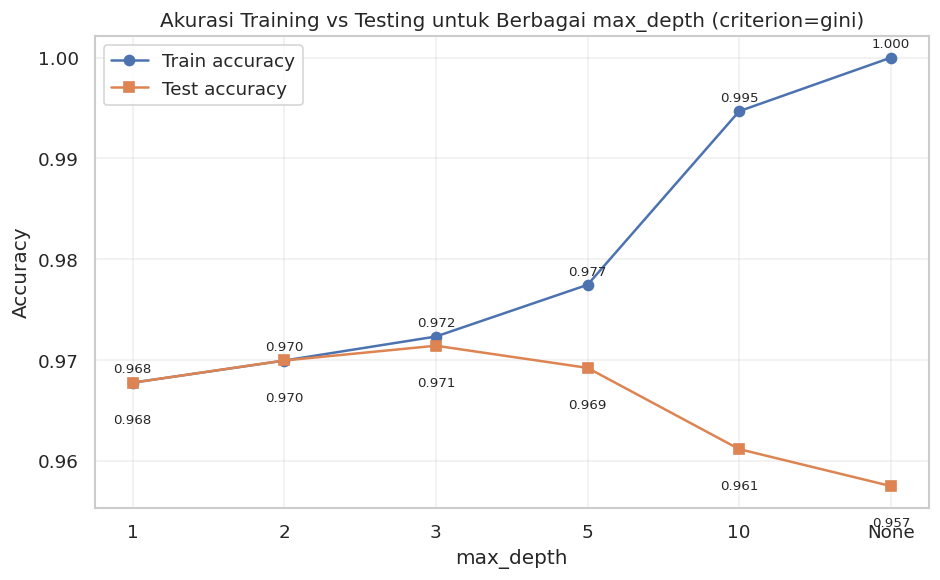

In [34]:
# Plot akurasi training vs testing terhadap max_depth
x = np.arange(len(depths))
labels = [str(d) for d in depths]
plt.figure(figsize=(8, 5))
plt.plot(x, train_acc, marker="o", label="Train accuracy")
plt.plot(x, test_acc, marker="s", label="Test accuracy")
plt.xticks(x, labels)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Akurasi Training vs Testing untuk Berbagai max_depth (criterion=gini)")
plt.legend()
plt.grid(True, alpha=0.3)
for i, (tr, te) in enumerate(zip(train_acc, test_acc)):
    plt.text(i, tr + 0.001, f"{tr:.3f}", ha="center", fontsize=8)
    plt.text(i, te - 0.004, f"{te:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [35]:
# Metrik evaluasi (Accuracy, Precision, Recall, F1) untuk Gini vs Entropy
def scores(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
    }

comparison = pd.DataFrame([scores(y_test, y_pred_gini), scores(y_test, y_pred_entropy)],
                          index=["Gini", "Entropy"]).round(4)
display(comparison)
print("\nClassification report - Gini:")
print(classification_report(y_test, y_pred_gini, digits=4, zero_division=0))
print("Classification report - Entropy:")
print(classification_report(y_test, y_pred_entropy, digits=4, zero_division=0))

,Accuracy,Precision,Recall,F1-Score
Gini,0.9575,0.3409,0.3409,0.3409
Entropy,0.9589,0.3571,0.3409,0.3488



Classification report - Gini:
              precision    recall  f1-score   support

           0     0.9780    0.9780    0.9780      1320
           1     0.3409    0.3409    0.3409        44

    accuracy                         0.9575      1364
   macro avg     0.6595    0.6595    0.6595      1364
weighted avg     0.9575    0.9575    0.9575      1364

Classification report - Entropy:
              precision    recall  f1-score   support

           0     0.9781    0.9795    0.9788      1320
           1     0.3571    0.3409    0.3488        44

    accuracy                         0.9589      1364
   macro avg     0.6676    0.6602    0.6638      1364
weighted avg     0.9580    0.9589    0.9585      1364



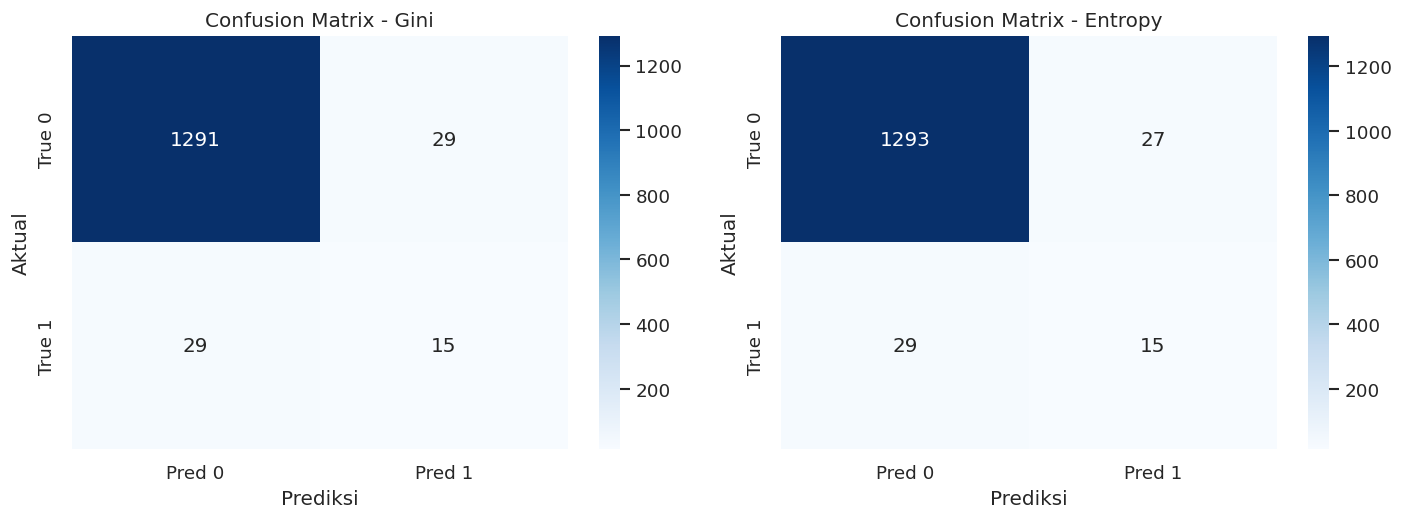

In [36]:
# Confusion Matrix Gini vs Entropy dalam satu baris subplot
cm_gini = confusion_matrix(y_test, y_pred_gini)
cm_ent = confusion_matrix(y_test, y_pred_entropy)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, cm, title in zip(axes, [cm_gini, cm_ent], ["Confusion Matrix - Gini", "Confusion Matrix - Entropy"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    ax.set_title(title)
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")
plt.tight_layout()
plt.show()

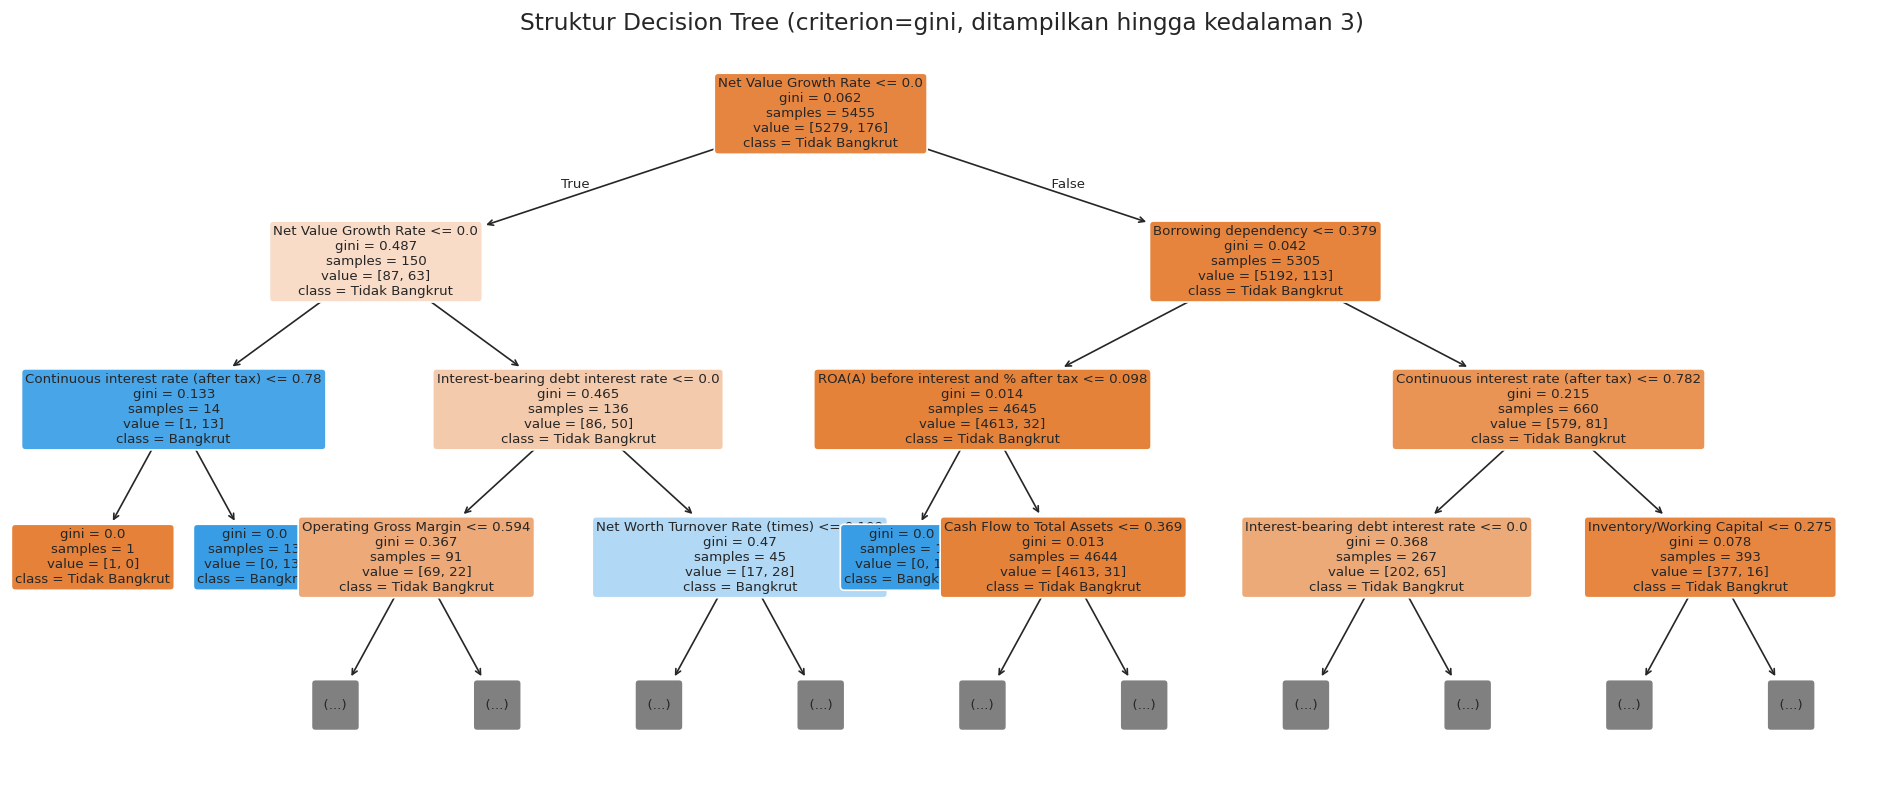

In [37]:
# Visualisasi struktur Decision Tree terbaik (Gini unggul tipis -> visualkan, batasi depth agar terbaca)
best_model = model_gini  # ganti ke model_entropy jika entropy lebih baik pada run kalian
plt.figure(figsize=(20, 8))
plot_tree(best_model, max_depth=3, feature_names=list(X.columns),
          class_names=["Tidak Bangkrut", "Bangkrut"],
          filled=True, rounded=True, fontsize=8, impurity=True)
plt.title("Struktur Decision Tree (criterion=gini, ditampilkan hingga kedalaman 3)", fontsize=14)
plt.show()

Cash/Current Liability                  0.0276
Continuous interest rate (after tax)    0.0438
Borrowing dependency                    0.0544
Interest-bearing debt interest rate     0.0689
Net Value Growth Rate                   0.1886
dtype: float64


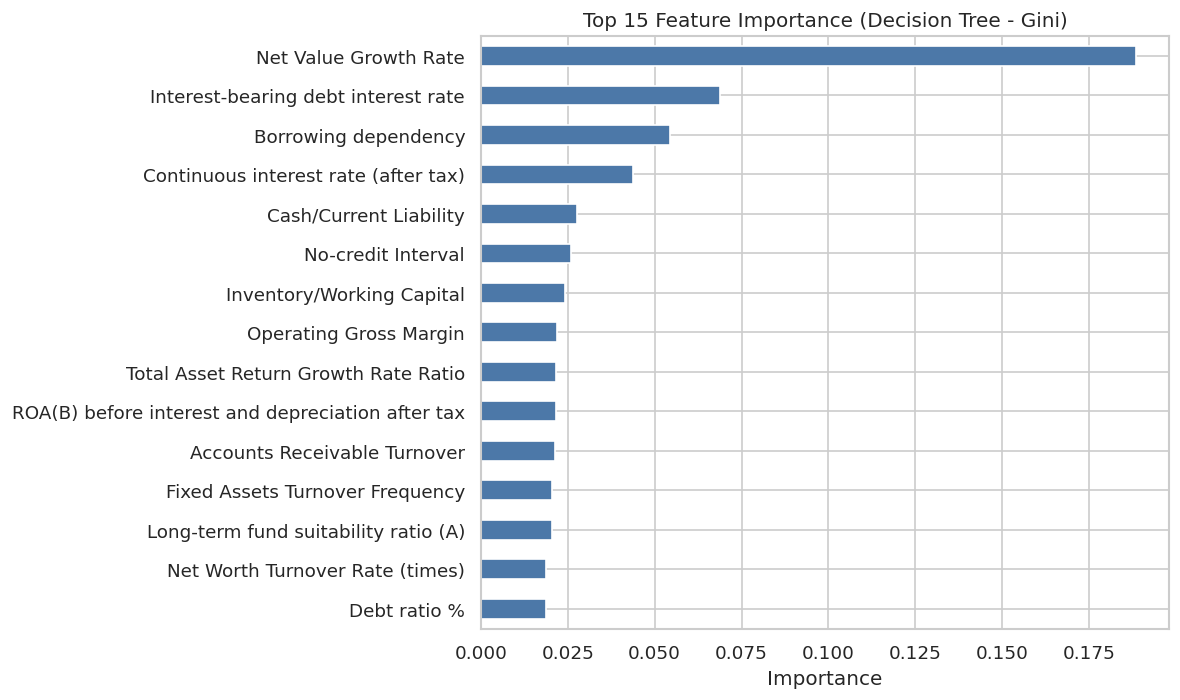

In [38]:
# Feature importance model terbaik dalam bar chart horizontal (Top 15)
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
top15 = importances.tail(15)
print(top15.tail(5).round(4))

plt.figure(figsize=(10, 6))
top15.plot(kind="barh", color="#4C78A8")
plt.title("Top 15 Feature Importance (Decision Tree - Gini)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# 5. Analisis

### Analisis hasil eksperimen

Dari eksperimen yang dilakukan, model Gini dan Entropy hasilnya hampir sama yaitu akurasi Gini sekitar 0,961 dan Entropy sekitar 0,959, jadi bedanya kecil dan tidak terlalu penting karena cara kerja keduanya memang mirip yaitu sama-sama mencari pemisah data yang paling bersih, sedangkan pada percobaan max_depth terlihat kalau pohon yang dibiarkan tumbuh terlalu dalam akan overfitting yang tandanya akurasi data training terus naik sampai 1,000 tapi akurasi data testing malah turun, dan titik yang paling pas ada di max_depth 3 karena di situ akurasi testing paling tinggi dengan selisih train dan test yang kecil, lalu dari feature importance fitur yang paling berpengaruh adalah Borrowing dependency yang artinya perusahaan yang terlalu bergantung pada pinjaman punya risiko bangkrut paling besar, disusul oleh Continuous interest rate, Persistent EPS, Net Value Growth Rate, dan Quick Ratio yang semuanya berhubungan dengan utang, keuntungan, dan kondisi keuangan perusahaan.

# 6. Kesimpulan dan Saran

### Kesimpulan dan Saran

Kesimpulannya model Decision Tree berhasil memprediksi kebangkrutan dengan akurasi sekitar 96 persen tetapi angka ini menipu karena datanya tidak seimbang sehingga yang lebih penting adalah nilai F1 yang masih rendah sekitar 0,35 sampai 0,39, lalu Gini sedikit lebih bagus dari Entropy tapi bedanya kecil, dan pohon yang terlalu dalam akan overfitting sehingga max_depth 3 adalah pilihan terbaik, sedangkan untuk saran ke depannya bisa mencoba class_weight balanced atau SMOTE supaya kelas bangkrut lebih diperhatikan, mencoba pruning dengan ccp_alpha atau min_samples_leaf, dan membandingkan dengan model lain seperti Random Forest atau XGBoost yang biasanya lebih kuat.